In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

In [95]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### 
    Data quality assessment identified 11 missing values in the Postal Code field. As this represented a negligible proportion of the dataset and did not affect the planned sales, customer, or regional analyses, the missing values were retained.

## Data Quality Assessment

In [36]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [35]:
null_values = df[df['Postal Code'].isnull()]
null_values

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [38]:
for column in df.columns:
    print(f"{column}: {df[column].dtype}")

Row ID: int64
Order ID: object
Order Date: object
Ship Date: object
Ship Mode: object
Customer ID: object
Customer Name: object
Segment: object
Country: object
City: object
State: object
Postal Code: float64
Region: object
Product ID: object
Category: object
Sub-Category: object
Product Name: object
Sales: float64


## Data transformation

In [96]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [97]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d/%m/%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d/%m/%Y'
)

####  
    During data quality assessment, the Order Date and Ship Date fields were stored as text objects. These columns were converted to datetime format using the %d/%m/%Y specification to enable time-series and shipping performance analysis.

## How much revenue did we generate?

In [8]:
total_revenue = df['Sales'].sum()
print(f'Total revenue: {total_revenue:.3f}')

Total revenue: 2261536.783


## Which months generated the highest sales?

In [75]:
highest_sales_month = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
highest_sales_month

Month
Nov    350161.7110
Dec    321480.1695
Sep    300103.4117
Oct    199496.2947
Mar    197573.5872
Aug    157315.9270
May    154086.7237
Jun    145837.5233
Jul    145535.6890
Apr    136283.0006
Jan     94291.6296
Feb     59371.1154
Name: Sales, dtype: float64

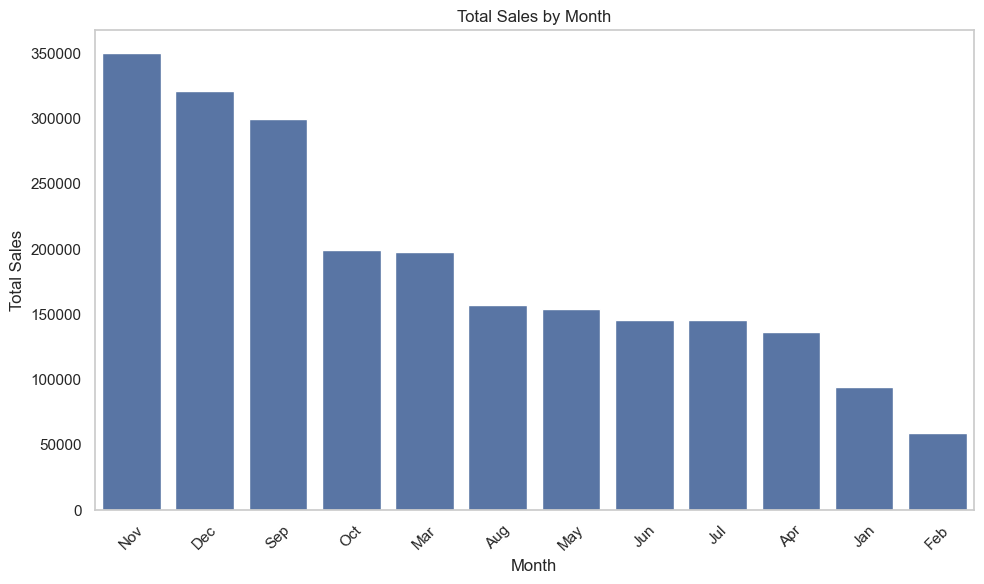

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=highest_sales_month.index,
    y=highest_sales_month.values
)

plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Product Questions
## Which product categories generate the most revenue?

In [39]:
sale_category = df.groupby('Category')['Sales'].sum()
print(f"highest_sale_category: {sale_category}")

highest_sale_category: Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


## Which sub-categories perform best?

In [16]:
sub_category = df.groupby('Sub-Category')['Sales'].sum()
print(f"Total sales by sub-cateogry")
print(sub_category)

Total sales by sub-cateogry
Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


## What are the top 10 products by revenue?

In [18]:
top_10_product = df.groupby('Product Name')['Sales'].sum().nlargest(10)
print(top_10_product)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


## Customer Questions
## Who are our most valuable customers?

In [21]:
top_10_cust = df.groupby('Customer Name')['Sales'].sum().nlargest(10)
print(top_10_cust)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


## Which customer segment spends the most?

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


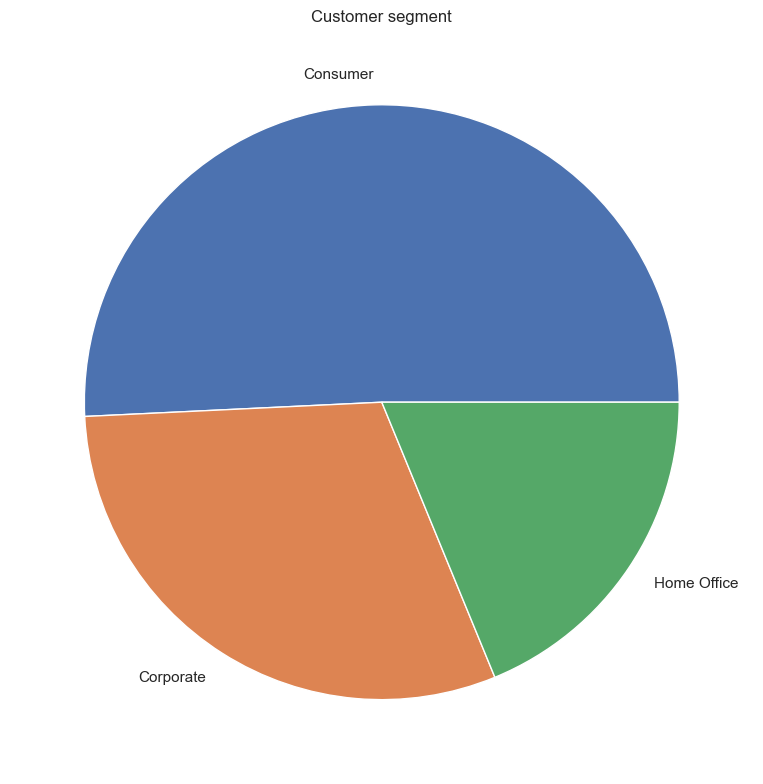

In [79]:
cust_segment = df.groupby('Segment')['Sales'].sum()
print(cust_segment)

plt.figure(figsize=(10,8))

plt.pie(cust_segment.values,
        labels=cust_segment.index)

plt.title("Customer segment")
plt.tight_layout()
plt.show()

## Regional Questions
## Which regions generate the most sales?

In [24]:
regional_sales = df.groupby('Region')['Sales'].sum()
print(regional_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


## Which states generate the highest sales?

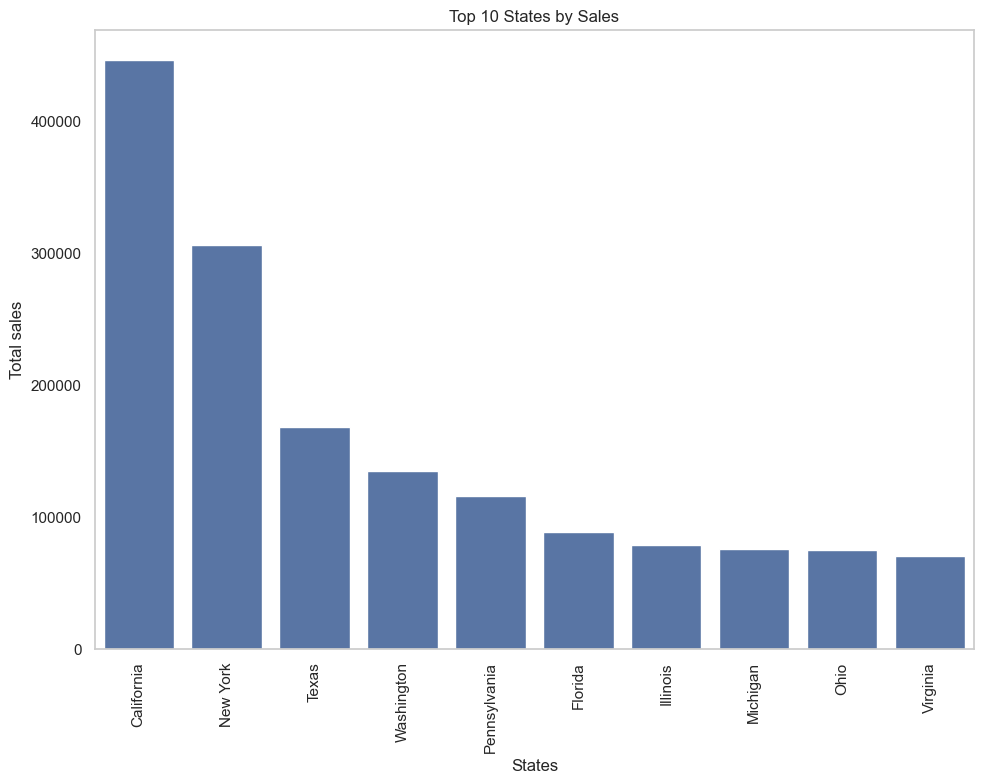

In [84]:
state_sales = df.groupby('State')['Sales'].sum().nlargest(10)

plt.figure(figsize=(10,8))
sns.barplot(y=state_sales.values,
            x=state_sales.index)

plt.title("Top 10 States by Sales")
plt.xlabel("States")
plt.ylabel("Total sales")
plt.xticks(rotation=90)
plt.grid(False)
plt.tight_layout()
plt.show()

## Which cities are our strongest markets?

In [27]:
city_sales = df.groupby('City')['Sales'].sum().nlargest(10)
print(city_sales)

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64


## Which shipping mode is used most?

In [28]:
most_shipping_mode = df['Ship Mode'].value_counts()
print(most_shipping_mode)

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


## How long does shipping take?

In [52]:
df['Shipping Days'] = (
    pd.to_datetime(df['Ship Date']) -
    pd.to_datetime(df['Order Date'])
).dt.days

subcategory_shipping = df.groupby('Sub-Category')['Shipping Days'].sum().sort_values(ascending=False)
print(subcategory_shipping)

Sub-Category
Binders        6017
Paper          5206
Furnishings    3704
Phones         3506
Storage        3309
Art            3185
Accessories    2937
Chairs         2369
Appliances     1832
Labels         1428
Tables         1225
Envelopes       994
Bookcases       862
Fasteners       848
Supplies        726
Machines        431
Copiers         240
Name: Shipping Days, dtype: int64


In [53]:
longest_Shipping = df.loc[df['Shipping Days'].idxmax()]
print(longest_Shipping)

Row ID                                                       4
Order ID                                        US-2016-108966
Order Date                                 2016-10-11 00:00:00
Ship Date                                  2016-10-18 00:00:00
Ship Mode                                       Standard Class
Customer ID                                           SO-20335
Customer Name                                   Sean O'Donnell
Segment                                               Consumer
Country                                          United States
City                                           Fort Lauderdale
State                                                  Florida
Postal Code                                            33311.0
Region                                                   South
Product ID                                     FUR-TA-10000577
Category                                             Furniture
Sub-Category                                           

## Trend Questions
## How have sales changed over time?

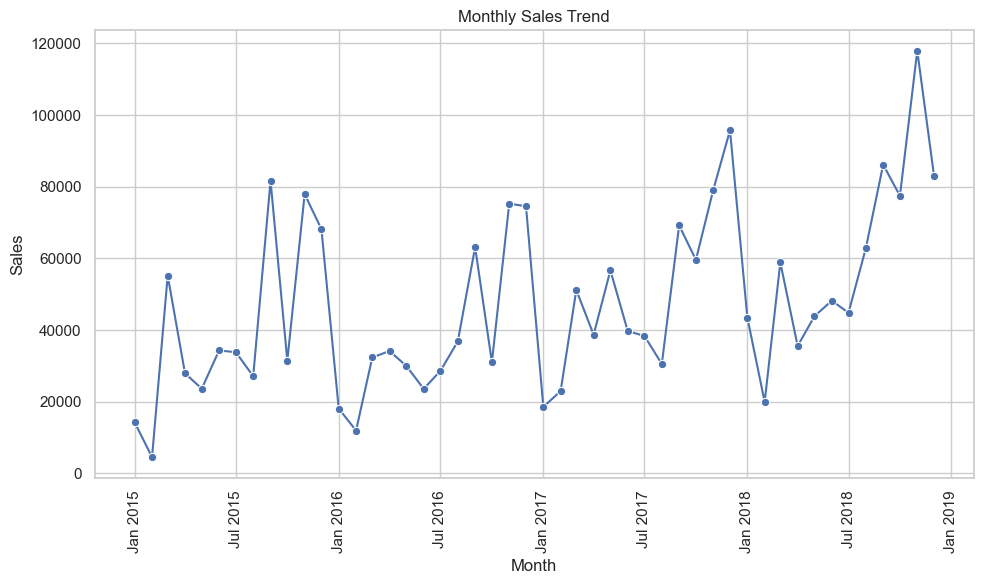

In [78]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))
      ['Sales']
      .sum()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_sales.index.to_timestamp(),
    y=monthly_sales.values,
    marker='o'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.xticks(rotation=90)
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [98]:
df['Order Date'] = df['Order Date'].dt.strftime('%Y-%m-%d')
df['Ship Date'] = df['Ship Date'].dt.strftime('%Y-%m-%d')

In [99]:
## Save tranformed data

df.to_excel(
    'superstore_cleaned_1.xlsx',
    index=False,
    engine='openpyxl'
)

## Dashboard Pages 
    Page 1: Executive Summary
        Total Revenue
        Total Orders
        Number of Customers
        Monthly Sales Trend
    Page 2: Product Performance
        Sales by Category
        Sales by Sub-category
        Top 10 Products
    Page 3: Customer Analysis
        Sales by Segment
        Top Customers
    Page 4: Geographic Analysis
        Sales by Region
        Sales by State
        Sales by City
    Page 5: Operations
        Shipping Modes
        Average Delivery Time